# Principal component analysis

## Why dimensionality reduction?

Real data sets often have many correlated or noisy features. Principal component analysis (PCA) finds a new set of axes — the *principal components* — along which the data varies the most, and re-expresses the data in terms of (typically far fewer of) these new axes. It is widely used both to visualize high-dimensional data and as a preprocessing step that reduces dimensionality before applying another model.

## Finding the principal components

PCA starts from the mean-centered data covariance matrix,

$$
\boldsymbol{\Sigma} = \frac{1}{N-1} \boldsymbol{X}^\top \boldsymbol{X}
$$

where $\boldsymbol{X}$ is the $N \times d$ data matrix with each feature column mean-centered. The principal components are the eigenvectors $\boldsymbol{v}_k$ of $\boldsymbol{\Sigma}$,

$$
\boldsymbol{\Sigma} \boldsymbol{v}_k = \lambda_k \boldsymbol{v}_k
$$

ordered by decreasing eigenvalue $\lambda_k$. The first component $\boldsymbol{v}_1$ points in the direction of maximum variance; the second, $\boldsymbol{v}_2$, is orthogonal to the first and captures the next-largest share, and so on. Each eigenvalue $\lambda_k$ equals the variance of the data along the corresponding component, so the fraction of total variance explained by the first $K$ components is $\sum_{k=1}^K \lambda_k / \sum_{k=1}^d \lambda_k$. Projecting onto the leading $K \ll d$ components gives the lower-dimensional representation that retains as much variance as possible.

## Library imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use the **wine data set** bundled with `sklearn`: 178 wine samples produced by three different cultivars in Italy, described by 13 chemical measurements (alcohol content, malic acid, colour intensity, flavonoids, etc.). Identifying groups of chemically similar wines and understanding which chemical properties drive the differences is a representative metabolomics or analytical-chemistry task.

In [2]:
wine = sklearn.datasets.load_wine()
X, y = wine.data, wine.target

print("Number of samples  :", X.shape[0])
print("Number of features :", X.shape[1])
print("Feature names      :", wine.feature_names)
print("Class names        :", list(wine.target_names))


Number of samples  : 178
Number of features : 13
Feature names      : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names        : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


Features span very different physical scales (alcohol in %, flavonoids in mg/g, colour intensity in absorbance units), so standardization is essential before applying PCA — Eq. (1) is based on variance, and without standardization, features with large absolute values would dominate the principal components for purely numerical reasons.

In [3]:
scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)


## Model definition and training

We fit PCA retaining all 13 components first, to inspect the explained variance, Eq. (2).

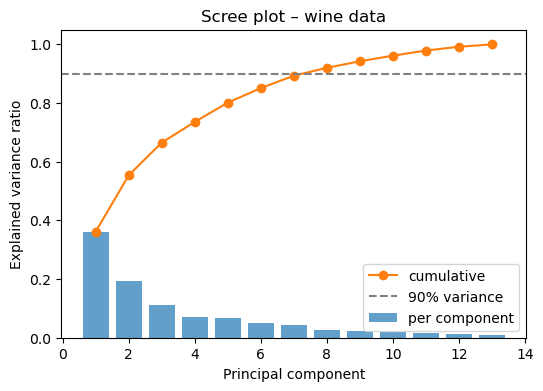

In [4]:
pca_full = sklearn.decomposition.PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(6, 4))
plt.bar(range(1, len(explained) + 1), explained, label="per component", color="tab:blue", alpha=0.7)
plt.plot(range(1, len(cumulative) + 1), cumulative, "o-", color="tab:orange", label="cumulative")
plt.axhline(0.90, color="gray", linestyle="--", label="90% variance")
plt.xlabel("Principal component"); plt.ylabel("Explained variance ratio")
plt.legend(); plt.title("Scree plot – wine data")
plt.show()


In [5]:
n_90 = np.searchsorted(cumulative, 0.90) + 1
print(f"{n_90} components explain ≥90% of the variance (out of {X.shape[1]} original features)")


8 components explain ≥90% of the variance (out of 13 original features)


## Projection onto two components

The first two principal components already explain a substantial fraction of the variance and allow us to visualize the three wine cultivars in 2D — without the PCA ever having seen the cultivar labels (PCA is unsupervised).

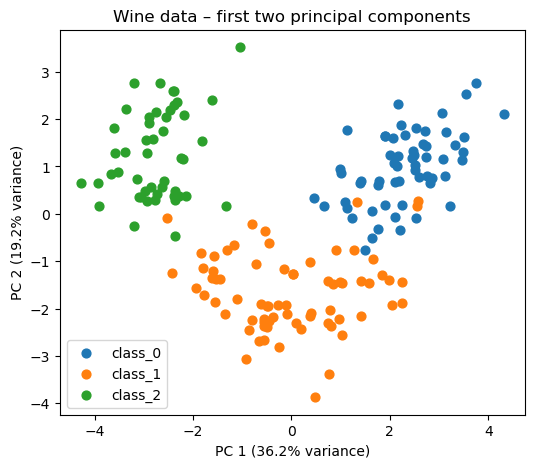

In [6]:
pca_2d = sklearn.decomposition.PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
for label, name in enumerate(wine.target_names):
    mask = y == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, s=40)
ax.set_xlabel(f"PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(); ax.set_title("Wine data – first two principal components")
plt.show()


The three cultivars separate clearly along the first two components, confirming that the 13 chemical measurements contain strong cultivar-specific signal, most of which is captured by just a handful of linear combinations.

## Feature loadings

The loading vectors (the columns of $\boldsymbol{V}$, assuming $\boldsymbol{v}_k$ represents the rows, Eq. (2)) show which original features contribute most to each component and can guide chemical interpretation.

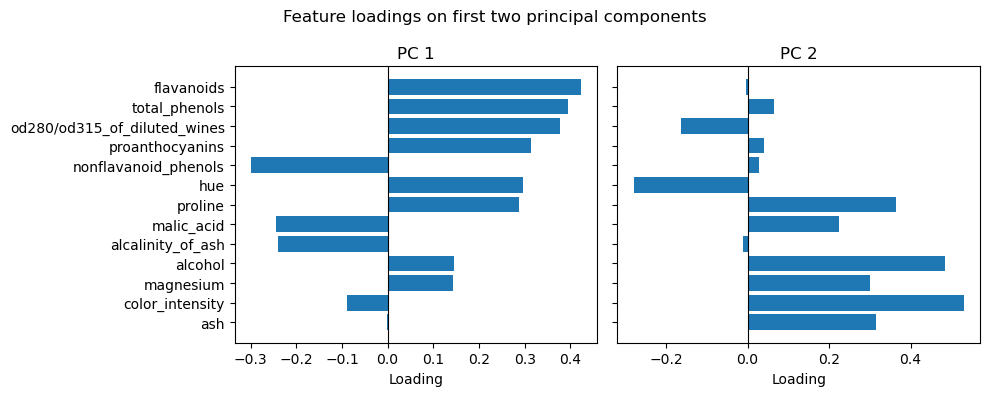

In [7]:
loadings = pca_full.components_[:2].T  # shape (n_features, 2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, ax in enumerate(axes):
    order = np.argsort(np.abs(loadings[:, i]))
    ax.barh(
        [wine.feature_names[j] for j in order],
        loadings[order, i],
    )
    ax.axvline(0, color="k", linewidth=0.8)
    ax.set_xlabel("Loading"); ax.set_title(f"PC {i+1}")
plt.suptitle("Feature loadings on first two principal components")
plt.tight_layout()
plt.show()


## Cross-validation and model selection

When PCA is used as a preprocessing step before a supervised model, the number of components $K$ is a hyperparameter that should be tuned with cross-validation rather than chosen by eye from the scree plot. `sklearn.pipeline.Pipeline` makes this straightforward: bundle `StandardScaler`, `PCA(n_components=K)`, and a classifier into one object, then pass it to `GridSearchCV` to find the $K$ that optimizes cross-validated accuracy.

## Take-away

PCA is one of the cheapest and most reliable tools for exploring and compressing tabular or spectroscopic data with limited resources: it has a closed-form solution, Eqs. (1)–(2) (no iterative training, no random initialization), and gives a principled, quantitative answer to how many components are needed. Its main limitation is that it only captures *linear* structure — the autoencoder notebook revisits the same dimensionality reduction idea with a *nonlinear* model.